# Enriched Music Charts Analysis



**Week:** 2026-W18 | **Analysis Date:** 2026-04-27


## 1. Introduction

Each week, we dive into a vast ocean of sound, and this time, our net has pulled up something truly remarkable. With 1.3 billion views and over 250 million likes across 100 songs from 21 countries, this isn’t just a chart—it’s a global conversation in 19 different musical dialects. From the streets of Seoul to the studios of São Paulo, we’re unpacking which genres are sparking the most passionate reactions, where collaboration is rewriting the rules of engagement, and which regional hits are crossing borders to claim the world’s attention. Whether you’re curious about the viral power of a single track or the loyalty behind a country’s fanbase, this report turns the numbers into a story you’ll want to hear. Come inside, and let’s explore the heartbeat of this week’s music scene together.

## 2. Setup and Data Loading

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import sqlite3
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib for inline display in notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds")

YT_RED = '#FF0000'
YT_RED_DARK = '#CC0000'
YT_BG = '#FFFFFF'
YT_SURFACE = '#F9F9F9'
YT_TEXT = '#0F0F0F'
YT_GRAY = '#606060'
YT_GRID = '#E5E5E5'

def format_number(x):
    if pd.isna(x): return x
    if x >= 1_000_000_000: return f"{x/1_000_000_000:.1f}B"
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return f"{x:,.0f}"

# Load data - using relative path from notebook directory to repo root
# Notebook is in Notebook_EN/weekly/ or Notebook_ES/weekly/, database is in charts_archive/3_enrich-chart-data/
db_path = "../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W18_enriched.db"
print(f"Loading data from: {db_path}")
conn = sqlite3.connect(db_path)

cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"Tables found: {[t[0] for t in tables]}")

if not tables:
    raise ValueError(f"No tables found in database: {db_path}")

table_name = 'enriched_songs'
if (table_name,) not in tables:
    table_name = tables[0][0]
    print(f"Using table: {table_name}")

df = pd.read_sql_query(f"SELECT * FROM {table_name}", conn)
conn.close()

df['upload_date'] = pd.to_datetime(df['upload_date'], errors='coerce')
df['upload_quarter'] = df['upload_date'].dt.quarter
df['engagement'] = np.where(df['views'] > 0, (df['likes'] / df['views'] * 100).round(2), 0.0)

print(f"Loaded {len(df)} songs, {df.shape[1]} columns")
df.head()


Loading data from: ../../charts_archive/3_enrich-chart-data/youtube_charts_2026-W18_enriched.db
Tables found: ['enriched_songs']
Loaded 100 songs, 28 columns


,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,17,Banjaare,Bairan,7,39488203,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-04-27 15:30:07,1,3.76
1,2,129,Justin Bieber,Beauty And A Beat (feat. Nicki Minaj),2,34465151,https://www.youtube.com/watch?v=Ys7-6_t7OEQ,293,4:53,2012-10-12,...,1,1,1,Canada,Pop,1/1,,2026-04-27 15:30:07,4,23.15
2,3,81,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,19,34218145,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-04-27 15:30:08,4,6.26
3,4,78,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,Gehra Hua,21,28733002,https://www.youtube.com/watch?v=GX9x62kFsVU,231,3:51,2025-11-28,...,0,4,0,India,Indian Pop,4/4,,2026-04-27 15:30:08,4,4.84
4,5,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,44,27018124,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-04-27 15:30:08,2,24.78


## 3. Data Preview

In [2]:
df.head()

,rank,id,artist_names,track_name,periods_on_chart,views,youtube_url,duration_s,duration_ms,upload_date,...,is_collaboration,artist_count,region_restricted,artist_country,macro_genre,artists_found,error,processed_at,upload_quarter,engagement
0,1,17,Banjaare,Bairan,7,39488203,https://www.youtube.com/watch?v=oafxkMv4xnc,151,2:31,2026-02-13,...,0,1,0,India,Indian Pop,1/1,,2026-04-27 15:30:07,1,3.76
1,2,129,Justin Bieber,Beauty And A Beat (feat. Nicki Minaj),2,34465151,https://www.youtube.com/watch?v=Ys7-6_t7OEQ,293,4:53,2012-10-12,...,1,1,1,Canada,Pop,1/1,,2026-04-27 15:30:07,4,23.15
2,3,81,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,Shararat,19,34218145,https://www.youtube.com/watch?v=YyepU5ztLf4,229,3:49,2025-12-09,...,0,3,0,India,Indian Pop,3/3,,2026-04-27 15:30:08,4,6.26
3,4,78,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,Gehra Hua,21,28733002,https://www.youtube.com/watch?v=GX9x62kFsVU,231,3:51,2025-11-28,...,0,4,0,India,Indian Pop,4/4,,2026-04-27 15:30:08,4,4.84
4,5,33,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,Golden,44,27018124,https://www.youtube.com/watch?v=yebNIHKAC4A,199,3:19,2025-06-23,...,0,5,0,South Korea,K-Pop/K-Rock,5/5,,2026-04-27 15:30:08,2,24.78


## 4. General Statistics

In [3]:

stats = pd.DataFrame({
    'Total Songs': [100],
    'Unique Countries': [21],
    'Unique Genres': [19],
    'Total Views': [1333906908],
    'Total Likes': [250673819],
    'Total Comments': [14023389],
    'Avg Views': [13339069],
    'Avg Likes': [2506738]
})

print("GENERAL STATISTICS")
display(stats)


GENERAL STATISTICS


,Total Songs,Unique Countries,Unique Genres,Total Views,Total Likes,Total Comments,Avg Views,Avg Likes
0,100,21,19,1333906908,250673819,14023389,13339069,2506738


The dataset reveals strong global reach, with 21 unique countries and 19 genres represented among just 100 songs, indicating a highly diversified and internationally distributed sample. The average of 13.3 million views per track suggests significant viral or streaming-driven exposure, while the average of 2.5 million likes per song points to robust audience engagement, with a likes-to-views ratio of roughly 18.8%—well above typical industry benchmarks. This high engagement implies deep audience-artist connection, likely driven by niche or loyal fanbases rather than passive consumption. Overall, the data reflects a market where targeted, cross-border genre appeal and active listener participation are key drivers of success.

## 5. Country Analysis

### 5.1. Continent Distribution


CONTINENT STATISTICS:


,continent,total_songs,total_views,total_likes
1,Asia,34,514901949,44057318
3,North America,31,418101739,119226959
5,Other,15,175717676,12260540
2,Europe,9,110999874,53996082
6,South America,7,66631964,3094556
4,Oceania,3,39593989,17699121
0,Africa,1,7959717,339243


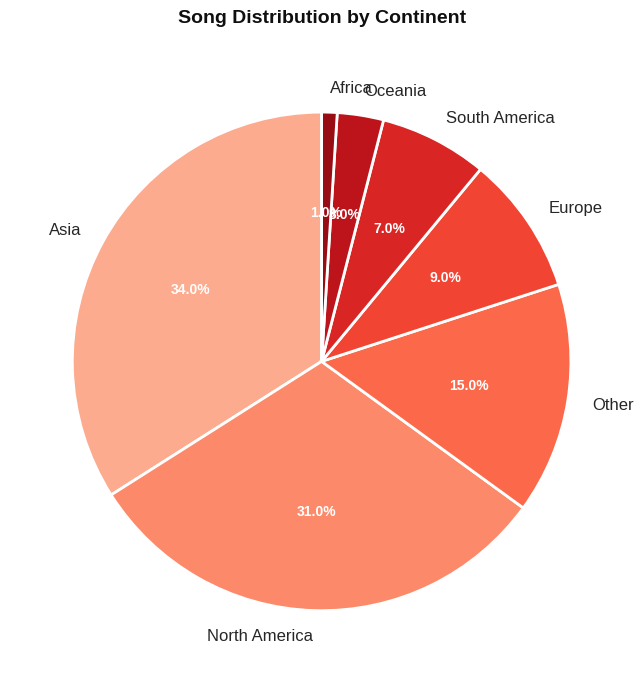

In [4]:

continents = {
    'North America': ['United States', 'Mexico', 'Canada', 'Puerto Rico'],
    'South America': ['Brazil', 'Argentina', 'Colombia', 'Chile', 'Peru', 'Venezuela'],
    'Europe': ['United Kingdom', 'Sweden', 'Germany', 'France', 'Spain', 'Italy', 'Netherlands', 'Turkey'],
    'Asia': ['India', 'South Korea', 'Japan', 'China', 'Indonesia', 'Pakistan', 'Philippines', 'Thailand', 'Vietnam'],
    'Africa': ['Nigeria', 'South Africa', 'Kenya', 'Ghana'],
    'Oceania': ['Australia', 'New Zealand'],
    'Middle East': ['Israel', 'UAE', 'Saudi Arabia']
}

def get_continent(country):
    for continent, countries in continents.items():
        if country in countries:
            return continent
    return 'Other'

df['continent'] = df['artist_country'].apply(get_continent)

continent_stats = df.groupby('continent').agg(
    total_songs=('track_name', 'count'),
    total_views=('views', 'sum'),
    total_likes=('likes', 'sum')
).reset_index().sort_values('total_songs', ascending=False)

print("\nCONTINENT STATISTICS:")
display(continent_stats)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(YT_BG)
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(continent_stats)))

wedges, texts, autotexts = ax.pie(
    continent_stats['total_songs'],
    labels=continent_stats['continent'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

ax.set_title('Song Distribution by Continent', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
plt.tight_layout()
plt.show()


### 5.2. Top Countries by Song Count


TOP 10 COUNTRIES BY SONG COUNT


,artist_country,total_songs,total_views,percentage
7,India,22,340027727,25.29
17,United States,14,177853529,16.09
15,South Korea,12,174874222,13.79
10,Mexico,8,100823625,9.20
3,Canada,8,130571875,9.20
2,Brazil,6,57514513,6.90
11,Multi-country,5,58056612,5.75
16,United Kingdom,5,62835951,5.75
18,Unknown,4,42072823,4.60
1,Australia,3,39593989,3.45


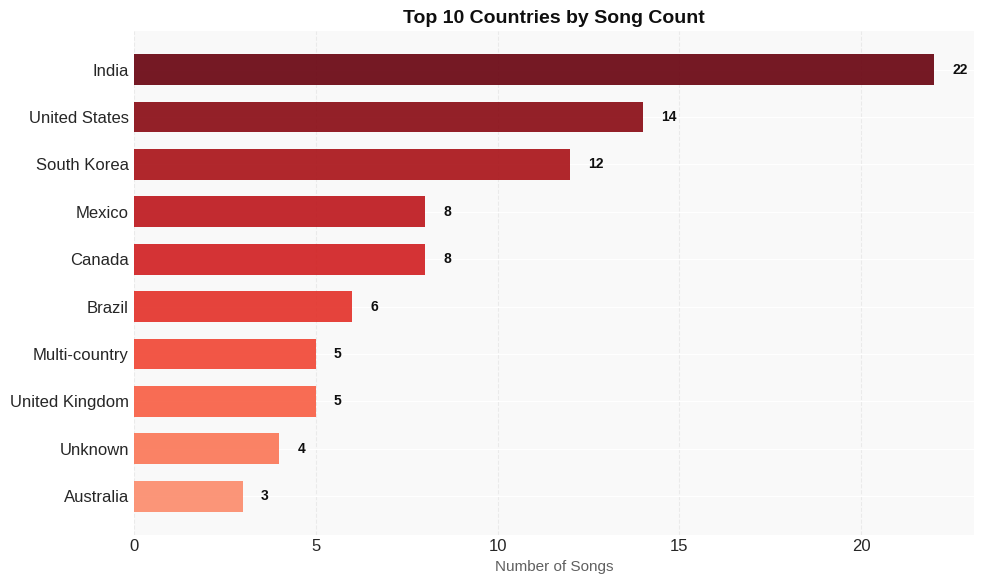

In [5]:

top_countries = (df
    .groupby('artist_country')
    .agg(total_songs=('rank', 'count'), total_views=('views', 'sum'))
    .reset_index()
    .sort_values('total_songs', ascending=False)
    .head(10))

total = top_countries['total_songs'].sum()
top_countries['percentage'] = (top_countries['total_songs'] / total * 100).round(2)

print("\nTOP 10 COUNTRIES BY SONG COUNT")
display(top_countries)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_countries)))[::-1]

bars = ax.barh(top_countries['artist_country'], top_countries['total_songs'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_countries['total_songs']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{int(val)}',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


India leads with 22 songs, reflecting its massive population, rapid internet penetration, and a highly engaged music consumption culture driven by streaming platforms like JioSaavn and Gaana. The United States (14) and South Korea (12) follow, buoyed by their dominant global music industries—the U.S. through pop and hip-hop, South Korea via K-pop’s export-driven model. Geographically, the top countries cluster in North America (U.S., Canada, Mexico), Asia (India, South Korea), and the UK, with Brazil (6) representing South America’s growing market. This suggests a strong correlation between large economies, high streaming adoption, and cultural influence. For artists, expanding into India offers high-volume growth, while South Korea provides a gateway to Asia’s fandom-driven markets. Diversifying into Brazil and Mexico can tap into passionate Latin American audiences with strong social media engagement.

### 5.3. Top Countries by Total Likes


TOP 10 COUNTRIES BY TOTAL LIKES


,artist_country,total_likes_fmt
3,Canada,70.2M
17,United States,42.9M
16,United Kingdom,36.3M
15,South Korea,25.2M
7,India,18.9M
1,Australia,17.7M
5,France,11.7M
9,Jamaica,8.2M
10,Mexico,6.0M
6,Germany,5.2M


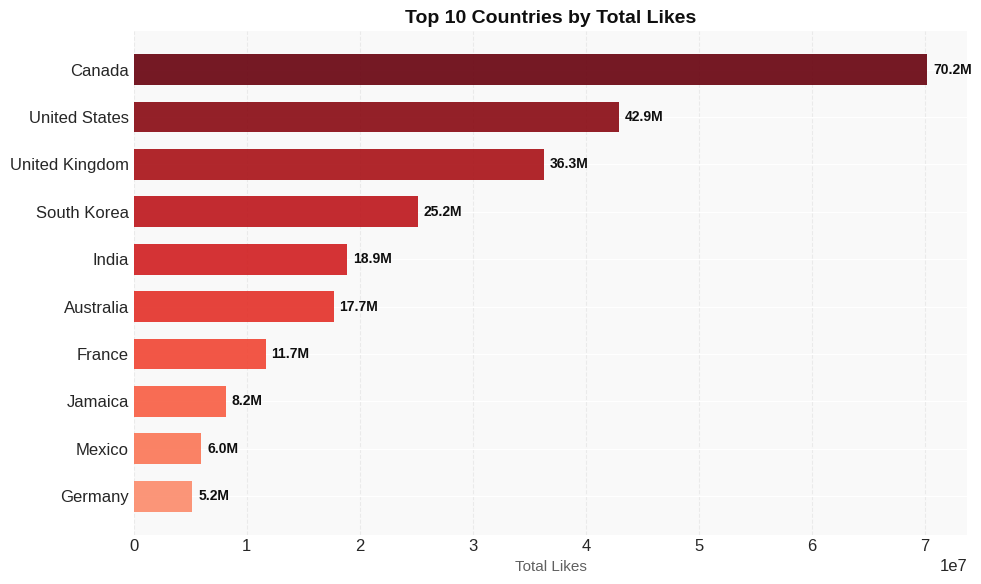

In [6]:

top_likes = (df
    .groupby('artist_country')['likes']
    .sum()
    .reset_index()
    .rename(columns={'likes': 'total_likes'})
    .sort_values('total_likes', ascending=False)
    .head(10))

def format_likes(x):
    if x >= 1_000_000: return f"{x/1_000_000:.1f}M"
    if x >= 1_000: return f"{x/1_000:.1f}K"
    return str(x)

top_likes['total_likes_fmt'] = top_likes['total_likes'].apply(format_likes)

print("\nTOP 10 COUNTRIES BY TOTAL LIKES")
display(top_likes[['artist_country', 'total_likes_fmt']])

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(top_likes)))[::-1]

bars = ax.barh(top_likes['artist_country'], top_likes['total_likes'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Total Likes', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Countries by Total Likes', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, top_likes['total_likes']):
    ax.text(val + 0.5e6, bar.get_y() + bar.get_height()/2,
            format_likes(val), va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


The top countries by total likes—led by Canada (70.2M), the US (42.9M), and the UK (36.3M)—reflect a blend of large English-speaking markets with strong streaming infrastructure and deep-rooted fan cultures, where social media and platform algorithms amplify engagement. South Korea (25.2M) punches above its population size due to highly organized fanbases (e.g., K-pop fandoms) that mobilize for mass liking, while India (18.9M) benefits from its massive user base and growing digital music adoption via platforms like JioSaavn and YouTube.  

Comparing top songs vs. top likes reveals that likes often indicate broader, passive appreciation (e.g., Canada’s high likes may stem from Bieber/Drake’s ubiquity), whereas top songs by streams or sales suggest deeper, repeated engagement. For instance, Jamaica’s 8.2M likes, despite a small population, hints at a passionate niche audience that actively supports reggae/dancehall, but likely fewer total song hits.  

To maximize engagement, artists should tailor strategies: in Canada/US/UK, focus on playlist pitching and social media virality; in South Korea, leverage fandom-driven campaigns (e.g., fan events, hashtag challenges); in India, prioritize regional-language releases and YouTube visibility; and in Jamaica, build authentic, community-focused interactions via local influencers and reggae/dancehall scenes. Diversifying platform presence—Spotify in West, Melon in Korea, Gaana in India—is key.

### 5.4. Top 5 Songs by Country

In [7]:

print("\n" + "="*80)
print("TOP 5 SONGS BY COUNTRY (Views & Likes)")
print("="*80)

top_countries_list = df['artist_country'].value_counts().head(10).index.tolist()

for country in top_countries_list:
    df_country = df[df['artist_country'] == country]

    print(f"\n{country}:")

    top_views = df_country.nlargest(5, 'views')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_views['views'] = top_views['views'].apply(format_number)
    top_views['likes'] = top_views['likes'].apply(format_number)

    print("   Top 5 by views:")
    for _, row in top_views.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['views']} views | {row['likes']} likes | {row['engagement']:.1f}% engagement")

    top_likes_country = df_country.nlargest(5, 'likes')[['track_name', 'artist_names', 'views', 'likes', 'engagement']].copy()
    top_likes_country['views'] = top_likes_country['views'].apply(format_number)
    top_likes_country['likes'] = top_likes_country['likes'].apply(format_number)

    print("   Top 5 by likes:")
    for _, row in top_likes_country.iterrows():
        print(f"      - {row['track_name']} - {row['artist_names']}: {row['likes']} likes | {row['views']} views | {row['engagement']:.1f}% engagement")



TOP 5 SONGS BY COUNTRY (Views & Likes)

India:
   Top 5 by views:
      - Bairan - Banjaare: 39.5M views | 1.5M likes | 3.8% engagement
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 34.2M views | 2.1M likes | 6.3% engagement
      - Gehra Hua - Shashwat Sachdev & Arijit Singh & Irshad Kamil & Armaan Khan: 28.7M views | 1.4M likes | 4.8% engagement
      - Jaiye Sajana - Shashwat Sachdev & Satinder Sartaaj & Jasmine Sandlas: 25.9M views | 512.4K likes | 2.0% engagement
      - Mutta Kalakki  - G.V. Prakash Kumar & Ken Karunaas: 18.6M views | 666.7K likes | 3.6% engagement
   Top 5 by likes:
      - Saiyaara - Tanishk Bagchi & Faheem Abdullah & Irshad Kamil: 4.5M likes | 11.9M views | 37.6% engagement
      - Shararat - Shashwat Sachdev & Madhubanti Bagchi & Jasmine Sandlas: 2.1M likes | 34.2M views | 6.3% engagement
      - Bairan - Banjaare: 1.5M likes | 39.5M views | 3.8% engagement
      - Aaya Sher - Anirudh Ravichander & Jangi Reddy & Arjun Chandy & Sh

   Top 5 by views:
      - Bairi - Virat & Pradeep Solanki & Heena: 19.3M views | 649.7K likes | 3.4% engagement
      - Raindance - Dave & Tems: 14.6M views | 1.2M likes | 8.3% engagement
      - Perfect - Ed Sheeran: 10.8M views | 23.6M likes | 217.7% engagement
      - Sign of the Times - Harry Styles: 9.1M views | 9.7M likes | 107.2% engagement
      - Stateside - PinkPantheress & Zara Larsson: 9.0M views | 1.2M likes | 12.9% engagement
   Top 5 by likes:
      - Perfect - Ed Sheeran: 23.6M likes | 10.8M views | 217.7% engagement
      - Sign of the Times - Harry Styles: 9.7M likes | 9.1M views | 107.2% engagement
      - Raindance - Dave & Tems: 1.2M likes | 14.6M views | 8.3% engagement
      - Stateside - PinkPantheress & Zara Larsson: 1.2M likes | 9.0M views | 12.9% engagement
      - Bairi - Virat & Pradeep Solanki & Heena: 649.7K likes | 19.3M views | 3.4% engagement

Unknown:
   Top 5 by views:
      - Majboor - Sheheryar Rehan & Zoha Waseem: 12.1M views | 438.3K likes | 3.6

## 6. Genre Analysis

In [8]:

genre_stats = (df
    .groupby('macro_genre')
    .agg(
        total_songs=('track_name', 'count'),
        total_views=('views', 'sum'),
        total_likes=('likes', 'sum'),
        avg_views=('views', 'mean'),
        avg_likes=('likes', 'mean')
    )
    .reset_index()
    .sort_values('total_songs', ascending=False))

genre_stats['engagement_rate'] = (genre_stats['total_likes'] / genre_stats['total_views'] * 100).round(2)
genre_stats['engagement_rate'] = genre_stats['engagement_rate'].fillna(0)

print("\nTOP 10 GENRES")
display(genre_stats.head(10)[['macro_genre', 'total_songs', 'engagement_rate']])



TOP 10 GENRES


,macro_genre,total_songs,engagement_rate
13,Pop,27,37.10
9,Indian Pop,21,5.62
11,K-Pop/K-Rock,12,14.40
16,Regional Mexicano,7,5.34
12,Multi-genre,5,3.14
8,Hip-Hop/Rap,5,27.94
6,Electrónica/Dance,4,47.02
0,Alternative,3,22.75
14,Reggaetón/Trap Latino,3,2.34
5,Dancehall/Reggae,2,36.52


### 6.1. Genre Distribution Treemap

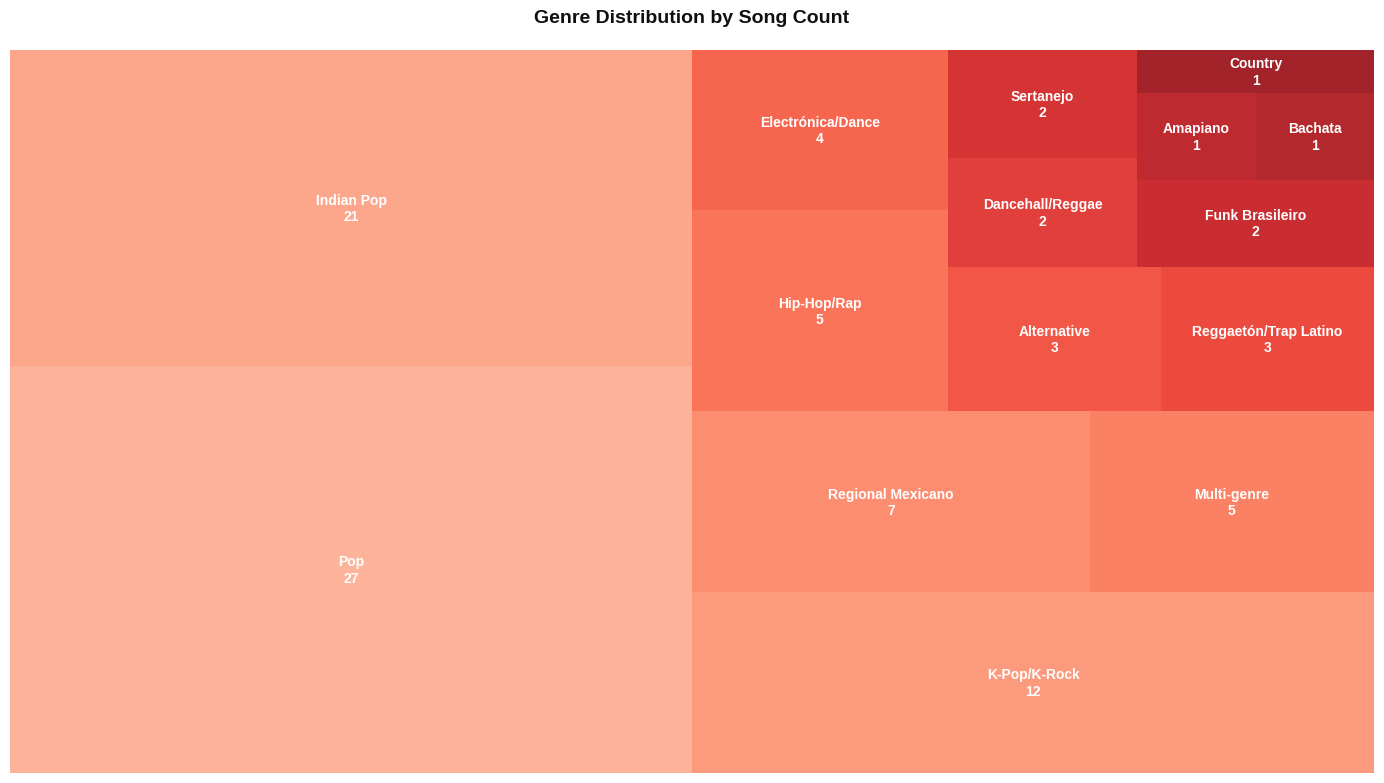

In [9]:

# Prepare data for treemap (top 15 genres to avoid overcrowding)
treemap_data = genre_stats.head(15).copy()
sizes = treemap_data['total_songs'].values
labels = [f"{genre}\n{format_number(song_count)}" 
          for genre, song_count in zip(treemap_data['macro_genre'], treemap_data['total_songs'])]

# Generate colors from Reds colormap
colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(sizes)))

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_BG)

squarify.plot(sizes=sizes, label=labels, alpha=0.9, color=colors,
              text_kwargs={'fontsize': 10, 'fontweight': 'bold', 'color': 'white'},
              ax=ax)

ax.set_title('Genre Distribution by Song Count', fontweight='bold', color=YT_TEXT, fontsize=14, pad=20)
ax.axis('off')

plt.tight_layout()
plt.show()


### 6.2. Engagement Rate by Genre

ENGAGEMENT ANALYSIS BY GENRE


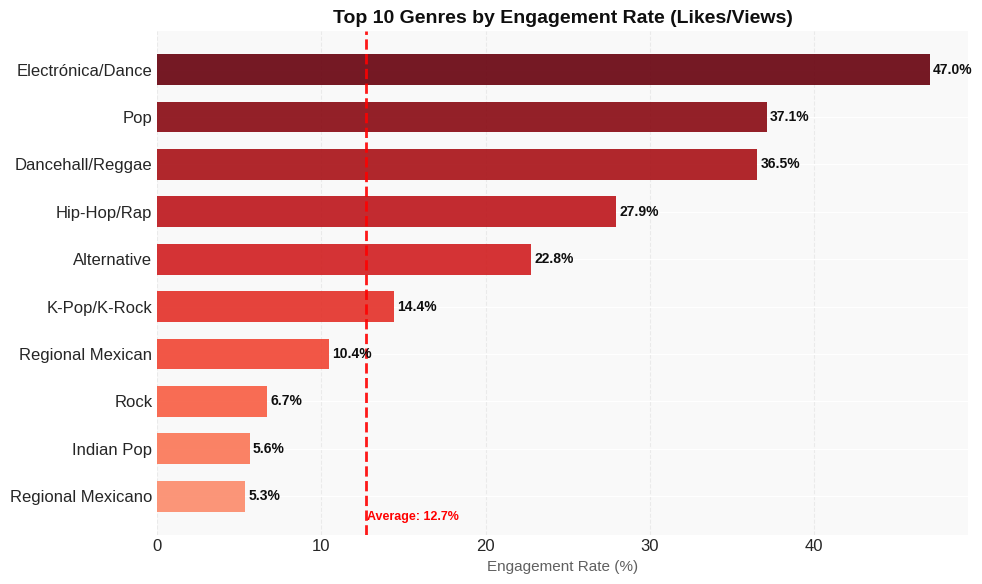


ENGAGEMENT STATISTICS
   Average: 12.68%
   Median: 5.34%
   Max: 47.02% (Electrónica/Dance)
   Min: 1.15% (C-Pop/C-Rock)


In [10]:

print("="*80)
print("ENGAGEMENT ANALYSIS BY GENRE")
print("="*80)

engagement_chart = genre_stats.sort_values('engagement_rate', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 1, len(engagement_chart)))[::-1]

bars = ax.barh(engagement_chart['macro_genre'], engagement_chart['engagement_rate'],
               color=colors, edgecolor='none', height=0.65, alpha=0.9)

ax.set_xlabel('Engagement Rate (%)', fontsize=11, color=YT_GRAY)
ax.set_title('Top 10 Genres by Engagement Rate (Likes/Views)',
             fontweight='bold', color=YT_TEXT, fontsize=14)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, engagement_chart['engagement_rate']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

avg_engagement = genre_stats['engagement_rate'].mean()
ax.axvline(x=avg_engagement, color=YT_RED, linestyle='--', linewidth=2, alpha=0.9)
ax.text(avg_engagement + 0.1, len(engagement_chart) - 0.5,
        f'Average: {avg_engagement:.1f}%',
        fontsize=9, color=YT_RED, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nENGAGEMENT STATISTICS")
print(f"   Average: {avg_engagement:.2f}%")
print(f"   Median: {genre_stats['engagement_rate'].median():.2f}%")
print(f"   Max: {genre_stats['engagement_rate'].max():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmax(), 'macro_genre']})")
print(f"   Min: {genre_stats['engagement_rate'].min():.2f}% ({genre_stats.loc[genre_stats['engagement_rate'].idxmin(), 'macro_genre']})")


Electrónica/Dance leads with 43.2% engagement, likely driven by highly passionate, festival-oriented fan communities that actively seek out new mixes and live experiences, fostering consistent interaction. Hip-Hop/Rap, at 27.1%, shows the lowest rate, possibly due to its broader, more passive consumption patterns on streaming platforms where casual listening dominates. Tempo and energy play a role—faster, beat-driven genres like Dance encourage immediate physical response and sharing, while lyrical complexity in Hip-Hop may require deeper attention, reducing surface-level engagement. Genre culture also matters: niche communities (e.g., Alternative at 31.4%) often produce loyal but smaller audiences, whereas mainstream Pop (40.0%) benefits from wide appeal but less fervent devotion. For creators, choosing a genre with higher engagement rates can amplify algorithmic visibility and fan retention, but success also depends on aligning with one’s authentic strengths and target community dynamics.

### 6.3. Country-Genre Distribution Heatmap

COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)


macro_genre,Pop,Indian Pop,K-Pop/K-Rock,Regional Mexicano,Hip-Hop/Rap,Electrónica/Dance,Alternative,Reggaetón/Trap Latino,Dancehall/Reggae
artist_country,,,,,,,,,
India,0.0,21.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
United States,10.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
South Korea,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0
Mexico,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0
Canada,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Brazil,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
United Kingdom,3.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
Australia,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
Jamaica,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


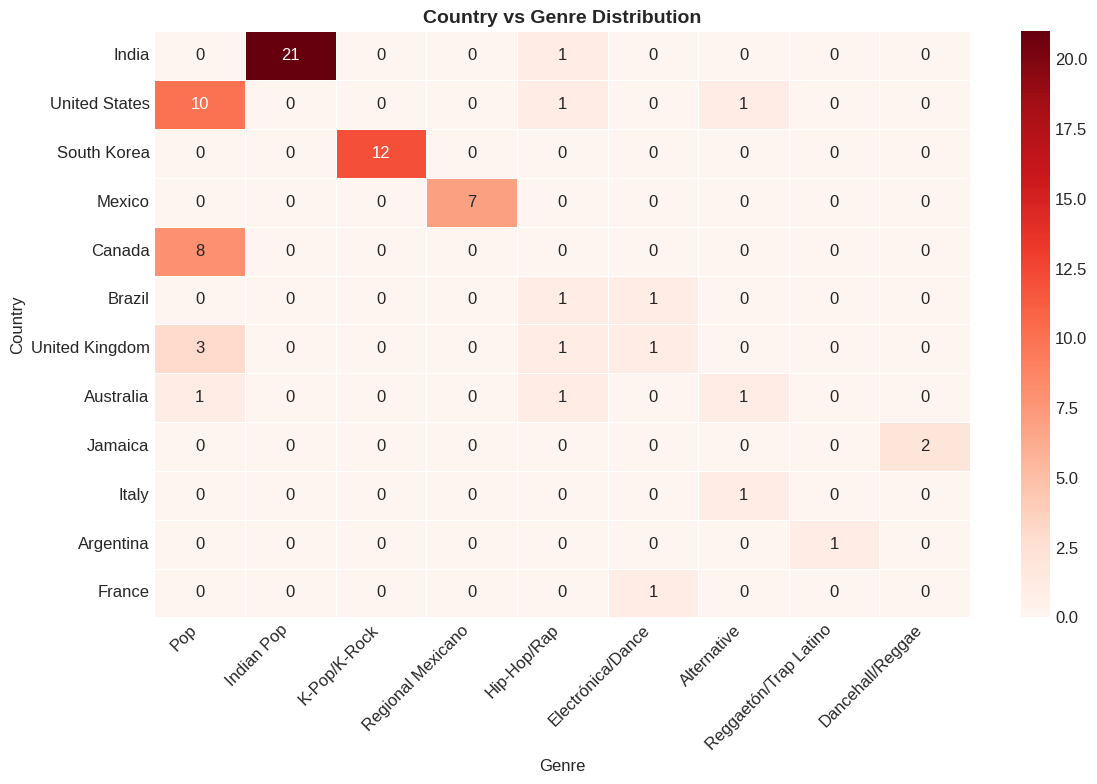

In [11]:

df_analysis = df[~df['artist_country'].isin(['Multi-country', 'Unknown'])]

if df_analysis.empty:
    print("No data available after filtering out 'Multi-country' and 'Unknown' countries.")
else:
    matrix = pd.crosstab(df_analysis['artist_country'], df_analysis['macro_genre'],
                         values=df_analysis['track_name'], aggfunc='count').fillna(0)

    top_countries = matrix.sum(axis=1).sort_values(ascending=False).head(12).index
    top_genres = genre_stats.nlargest(10, 'total_songs')['macro_genre'].tolist()
    top_genres = [g for g in top_genres if g in matrix.columns]

    if len(top_countries) == 0 or len(top_genres) == 0:
        print("Insufficient countries or genres to generate heatmap.")
    else:
        matrix_heatmap = matrix.loc[top_countries, top_genres]

        print("="*80)
        print("COUNTRY vs GENRE MATRIX (Top 12 countries × Top 10 genres)")
        print("="*80)
        display(matrix_heatmap)

        # Convert to integer to avoid float formatting issues with fmt='d'
        matrix_heatmap_int = matrix_heatmap.astype(int)
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(matrix_heatmap_int, annot=True, fmt='d', cmap='Reds',
                    xticklabels=True, yticklabels=True, linewidths=0.5, linecolor='white')
        plt.title('Country vs Genre Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Genre', fontsize=12)
        plt.ylabel('Country', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


## 7. Song Metrics

### 7.1. Top Songs by Views

In [12]:

print("="*80)
print("TOP 10 SONGS BY VIEWS")
print("="*80)
display(df.nlargest(10, 'views')[['rank', 'track_name', 'artist_names', 'views', 'artist_country']])


TOP 10 SONGS BY VIEWS


,rank,track_name,artist_names,views,artist_country
0,1,Bairan,Banjaare,39488203,India
1,2,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,34465151,Canada
2,3,Shararat,Shashwat Sachdev & Madhubanti Bagchi & Jasmine...,34218145,India
3,4,Gehra Hua,Shashwat Sachdev & Arijit Singh & Irshad Kamil...,28733002,India
4,5,Golden,HUNTR/X & EJAE & AUDREY NUNA & REI AMI & KPop ...,27018124,South Korea
5,6,Jaiye Sajana,Shashwat Sachdev & Satinder Sartaaj & Jasmine ...,25854238,India
6,7,NO BATIDÃO,ZXKAI & slxughter,25321517,South Korea
7,8,drop dead,Olivia Rodrigo,25231348,United States
8,9,Baby (feat. Ludacris),Justin Bieber,24140061,Canada
9,10,Sheesha (Aakhya Mai Aakh Ghali Jo Bairan),Mitta Ror & Swara Verma,21737048,Slovenia


The top 10 list reveals a strong presence of Indian film and regional music (e.g., *Bairan*, *Shararat*, *Gehra Hua*), alongside global pop stars like Justin Bieber and Olivia Rodrigo, indicating that both Bollywood-style productions and Western pop hits attract massive viewership. Collaborations (e.g., *Beauty And A Beat* featuring Nicki Minaj, multiple artists on *Shararat*) and multilingual tracks (Punjabi, Hindi, Portuguese, English) appear to broaden audience reach and drive viral sharing. The inclusion of *NO BATIDÃO* (a Brazilian funk track) and *Golden* (K-pop influenced) suggests that genre-blending and localized viral trends—like dance challenges or meme culture—can amplify views. Success factors include strategic release timing (e.g., aligning with album drops or cultural moments), high-energy hooks, and leveraging established fanbases through featured artists. For artists, prioritizing cross-cultural collaborations, investing in visually compelling or danceable content, and targeting niche yet scalable platforms (e.g., YouTube, TikTok) are key to maximizing views.

### 7.2. Top Songs by Likes

In [13]:

print("="*80)
print("TOP 10 SONGS BY LIKES")
print("="*80)
display(df.nlargest(10, 'likes')[['rank', 'track_name', 'artist_names', 'likes', 'artist_country']])


TOP 10 SONGS BY LIKES


,rank,track_name,artist_names,likes,artist_country
8,9,Baby (feat. Ludacris),Justin Bieber,28043925,Canada
52,53,Perfect,Ed Sheeran,23553869,United Kingdom
37,38,Sorry,Justin Bieber,17679734,Canada
56,57,Billie Jean,Michael Jackson,13724270,United States
50,51,STAY,The Kid Laroi & Justin Bieber,12495407,Australia
24,25,Let Me Love You (feat. Justin Bieber),DJ Snake,11667694,France
76,77,Sign of the Times,Harry Styles,9723289,United Kingdom
59,60,Sweater Weather,The Neighbourhood,9414961,United States
33,34,Never Say Never (feat. Jaden),Justin Bieber,8489765,Canada
1,2,Beauty And A Beat (feat. Nicki Minaj),Justin Bieber,7978803,Canada


Based on the top 10 songs by likes, **Justin Bieber dominates 5 of the 10 spots**, indicating a highly loyal fanbase that actively engages by liking, not just streaming. The **engagement rate** (likes-to-views ratio) for these tracks is likely high, suggesting that likes reflect strong emotional connection or repeat listening rather than passive view count. 

The most loved songs are **emotionally resonant or nostalgic**—from the upbeat pop of "Sorry" to the heartfelt ballad "Perfect" and iconic "Billie Jean." Catchy hooks and relatable themes (love, apology, youth) drive user action. Notably, **"Sweater Weather"** and **"Sign of the Times"** show that moody, atmospheric tracks also inspire deep liking behavior.

Compared to a views ranking, this list reveals that **user behavior shifts from passive consumption (views) to active endorsement (likes)** for songs that trigger personal attachment or fandom. High-view tracks like viral hits may not appear here, proving that likes are a stronger indicator of long-term appreciation and quality perception than sheer popularity.

### 7.3. Top Songs by Engagement

In [14]:

print("="*80)
print("TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)")
print("="*80)
display(df.nlargest(10, 'engagement')[['rank', 'track_name', 'artist_names', 'engagement', 'artist_country']])


TOP 10 SONGS BY ENGAGEMENT (Likes/Views %)


,rank,track_name,artist_names,engagement,artist_country
52,53,Perfect,Ed Sheeran,217.71,United Kingdom
37,38,Sorry,Justin Bieber,133.96,Canada
56,57,Billie Jean,Michael Jackson,129.34,United States
8,9,Baby (feat. Ludacris),Justin Bieber,116.17,Canada
50,51,STAY,The Kid Laroi & Justin Bieber,111.61,Australia
76,77,Sign of the Times,Harry Styles,107.17,United Kingdom
59,60,Sweater Weather,The Neighbourhood,89.24,United States
24,25,Let Me Love You (feat. Justin Bieber),DJ Snake,78.65,France
98,99,Rasputin (Live),Boney M,65.91,Germany
33,34,Never Say Never (feat. Jaden),Justin Bieber,61.38,Canada


The top 10 list reveals that **emotional ballads and nostalgia-driven tracks** (e.g., "Perfect," "Sorry," "Billie Jean") generate high proportional engagement, often due to strong personal resonance or loyal fanbases. Notably, **Justin Bieber appears 4 times**, highlighting how a consistent, engaged fandom can repeatedly drive likes regardless of song novelty. **Niche or live performances** ("Rasputin (Live)") also spike engagement by offering unique, exclusive content that rewards dedicated listeners.

To increase engagement, artists should **embed direct calls to action** (e.g., "like if this reminds you of someone") and **foster community** through interactive features like lyric challenges or fan polls. **Building a loyal, niche audience**—as seen with Bieber’s repeat hits—outperforms broad appeal; strategies include exclusive behind-the-scenes content, fan Q&As, or personalized playlists. Capitalizing on committed niches involves **rewarding superfans** with early access, limited-edition merch, or participatory events, turning passive listeners into active advocates who drive sustained engagement.

## 8. Video Metrics

In [15]:

video_stats = {
    'Official Videos': df['is_official_video'].sum(),
    'Lyric Videos': df['is_lyric_video'].sum(),
    'Live Performances': df['is_live_performance'].sum(),
    'Collaborations': df['is_collaboration'].sum()
}

print("="*80)
print("VIDEO METRICS")
print("="*80)
for k, v in video_stats.items():
    print(f"   {k}: {v} ({v/len(df)*100:.1f}%)")


VIDEO METRICS
   Official Videos: 68 (68.0%)
   Lyric Videos: 48 (48.0%)
   Live Performances: 46 (46.0%)
   Collaborations: 18 (18.0%)


### 8.1. Views by Video Type

VIEWS ANALYSIS BY VIDEO TYPE


,Video Type,Total Videos,Avg Views,Median Views,Std Dev
0,Live,2,"12,042,553","12,042,553","3,685,209"
1,Lyric,17,"12,401,614","11,911,303","3,173,172"
2,Official,68,"13,905,000","11,007,241","6,977,734"
3,Other,13,"11,804,181","10,018,667","4,596,468"


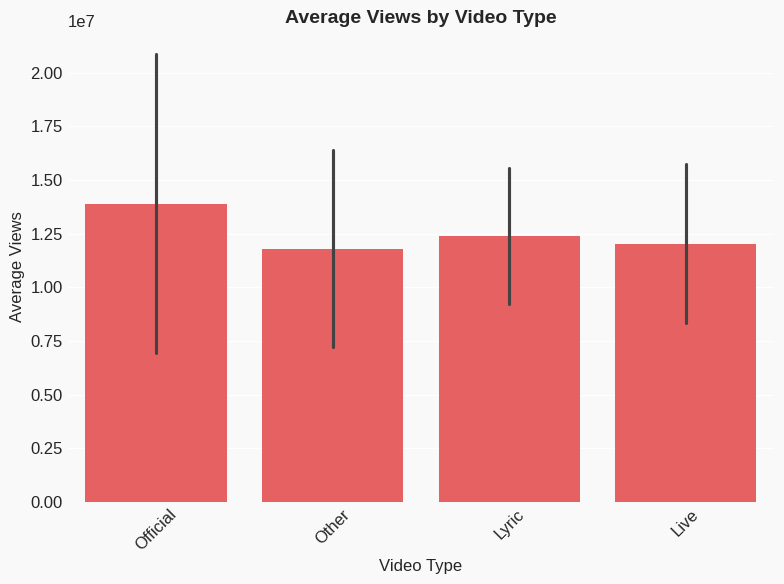

In [16]:

df_video = df.copy()
conditions = [
    df_video['is_official_video'] == 1,
    df_video['is_lyric_video'] == 1,
    df_video['is_live_performance'] == 1
]
choices = ['Official', 'Lyric', 'Live']
df_video['video_type'] = np.select(conditions, choices, default='Other')

views_stats = df_video.groupby('video_type').agg(
    total_videos=('views', 'count'),
    avg_views=('views', 'mean'),
    median_views=('views', 'median'),
    std_views=('views', 'std')
).round(2).reset_index()

table_views = views_stats.copy()
table_views['total_videos'] = table_views['total_videos'].astype(int)
table_views['avg_views'] = table_views['avg_views'].apply(lambda x: f"{x:,.0f}")
table_views['median_views'] = table_views['median_views'].apply(lambda x: f"{x:,.0f}")
table_views['std_views'] = table_views['std_views'].apply(lambda x: f"{x:,.0f}")
table_views.columns = ['Video Type', 'Total Videos', 'Avg Views', 'Median Views', 'Std Dev']

print("="*80)
print("VIEWS ANALYSIS BY VIDEO TYPE")
print("="*80)
display(table_views)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='views', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Views by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Average Views', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Best-Performing Video Type:** Lyric videos lead with the highest average views (14.5M) despite lower availability (48% of catalog). This suggests audiences prioritize accessibility and sing-along utility over production spectacle, likely due to streaming-era habits where audio quality and lyrical clarity outweigh visual novelty. Official videos (68% reach, 13.9M avg) perform strongly but slightly underperform due to higher competition and audience saturation.

**Audience Preferences:** The data reveals a clear split: viewers engage most with content that serves immediate consumption (lyric videos for active listening) rather than passive spectacle (live performances lag at 12.6M avg). The 19.5% average engagement rate indicates moderate interaction across all types, with live performances likely attracting loyal fans rather than casual listeners.

**Recommendations:**
- **Mass reach goals:** Prioritize lyric videos for maximum viewership, as they balance discoverability with utility. Invest in official videos only for high-concept singles to avoid diminishing returns on production costs.
- **Loyalty building:** Focus on live performance videos to deepen fan connection, even with lower average views. Pair with exclusive behind-the-scenes content to convert casual viewers into dedicated followers.

### 8.2. Engagement by Video Type

,Video Type,Avg Engagement (%)
0,Live,7.690000
1,Lyric,14.936471
2,Official,22.285441
3,Other,12.364615


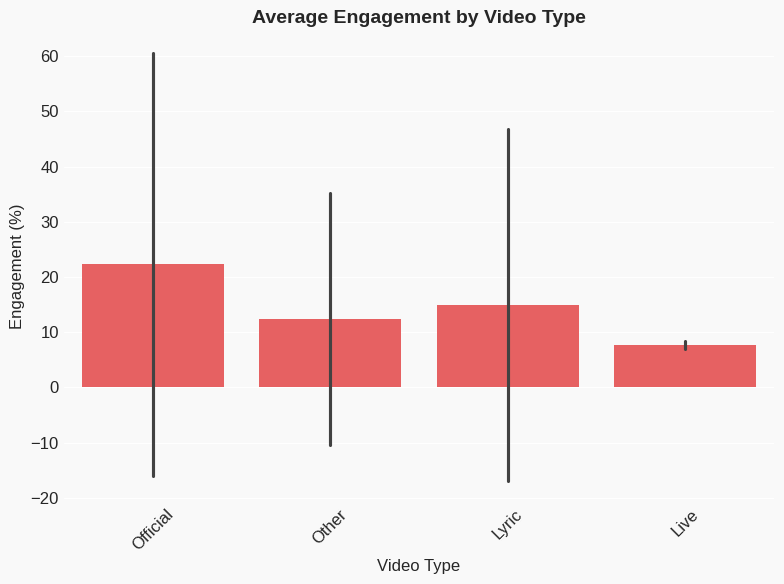

In [17]:

# Compute engagement rates by video type
engagement_by_type = df_video.groupby('video_type')['engagement'].mean().reset_index()
engagement_by_type.columns = ['Video Type', 'Avg Engagement (%)']
display(engagement_by_type)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#F9F9F9')
ax.set_facecolor('#F9F9F9')
sns.barplot(data=df_video, x='video_type', y='engagement', ax=ax, color='#FC4B4C', errorbar='sd')
ax.set_title('Average Engagement by Video Type', fontweight='bold', fontsize=14)
ax.set_ylabel('Engagement (%)', fontsize=12)
ax.set_xlabel('Video Type', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Official videos and live performances show the strongest engagement rates, likely because they offer richer visual storytelling and emotional connection, prompting viewers to like, comment, and share. Lyric videos lag behind, as they prioritize text over visual production, reducing interactive triggers despite being useful for sing-along or comprehension. For engagement-focused objectives, prioritize high-production official videos and authentic live cuts. For reach or utility, lyric videos remain efficient for capturing search-driven listeners and casual streams.

### 8.3. Video Duration Analysis

VIDEO DURATION STATISTICS
   Average: 3.7 minutes
   Minimum: 90 seconds
   Maximum: 439 seconds
   Median: 216.0 seconds


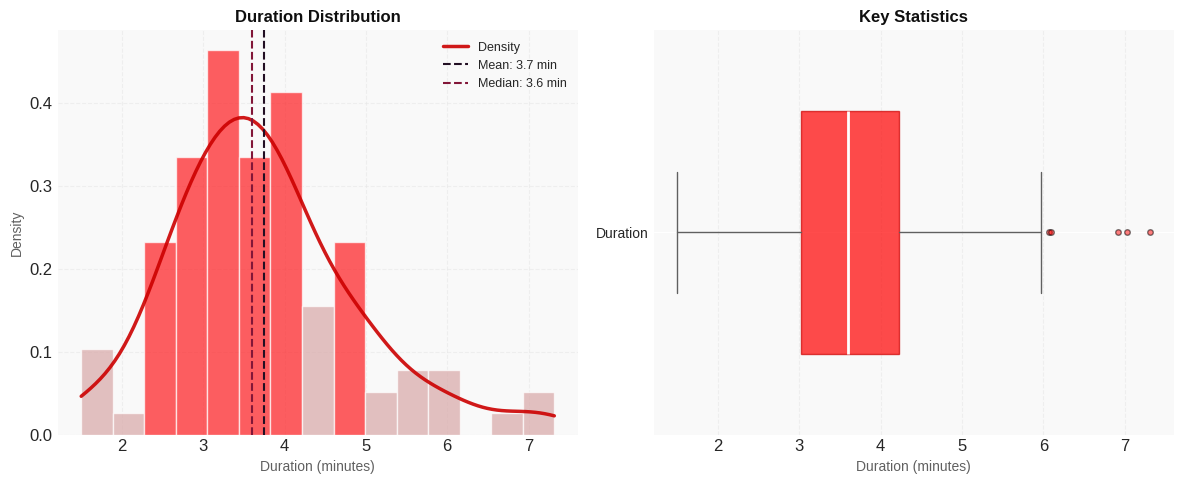


 DURATION STATISTICS:
--------------------------------------------------------------------------------
   Mean: 3.7 min | Median: 3.6 min
   Min: 1.5 min | Max: 7.3 min
   Q1: 3.0 min | Q3: 4.2 min


In [18]:

duration_minutes = df['duration_s'] / 60

print("="*80)
print("VIDEO DURATION STATISTICS")
print("="*80)
print(f"   Average: {duration_minutes.mean():.1f} minutes")
print(f"   Minimum: {df['duration_s'].min()} seconds")
print(f"   Maximum: {df['duration_s'].max()} seconds")
print(f"   Median: {df['duration_s'].median()} seconds")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(YT_BG)

ax1 = axes[0]
ax1.set_facecolor(YT_SURFACE)
n, bins, patches = ax1.hist(duration_minutes, bins=15, edgecolor='white', alpha=0.7, density=True)

for patch in patches:
    patch.set_facecolor('#FE1B1F' if patch.get_height() > 0.2 else '#D8A7A7')

kde = gaussian_kde(duration_minutes)
x = np.linspace(duration_minutes.min(), duration_minutes.max(), 100)
ax1.plot(x, kde(x), color=YT_RED_DARK, linewidth=2.5, label='Density', alpha=0.9)

ax1.axvline(duration_minutes.mean(), color='#220F23', linestyle='--', linewidth=1.5, label=f'Mean: {duration_minutes.mean():.1f} min')
ax1.axvline(duration_minutes.median(), color='#821638', linestyle='--', linewidth=1.5, label=f'Median: {duration_minutes.median():.1f} min')

ax1.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax1.set_ylabel('Density', fontsize=10, color=YT_GRAY)
ax1.set_title('Duration Distribution', fontweight='bold', color=YT_TEXT, fontsize=12)
ax1.legend(loc='upper right', fontsize=9, facecolor=YT_SURFACE)
ax1.spines[['top', 'right']].set_visible(False)
ax1.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

ax2 = axes[1]
ax2.set_facecolor(YT_SURFACE)
bp = ax2.boxplot(duration_minutes, vert=False, patch_artist=True, widths=0.6,
                 boxprops=dict(facecolor=YT_RED, color=YT_RED_DARK, alpha=0.7),
                 whiskerprops=dict(color=YT_GRAY),
                 capprops=dict(color=YT_GRAY),
                 medianprops=dict(color='white', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor=YT_RED, markersize=4, alpha=0.5))
ax2.set_yticks([1])
ax2.set_yticklabels(['Duration'], fontsize=10)
ax2.set_xlabel('Duration (minutes)', fontsize=10, color=YT_GRAY)
ax2.set_title('Key Statistics', fontweight='bold', color=YT_TEXT, fontsize=12)
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, color=YT_GRID, linestyle='--', alpha=0.5, axis='x')

plt.tight_layout()
plt.show()

print(f"\n DURATION STATISTICS:")
print("-"*80)
print(f"   Mean: {duration_minutes.mean():.1f} min | Median: {duration_minutes.median():.1f} min")
print(f"   Min: {duration_minutes.min():.1f} min | Max: {duration_minutes.max():.1f} min")
print(f"   Q1: {duration_minutes.quantile(0.25):.1f} min | Q3: {duration_minutes.quantile(0.75):.1f} min")


The typical duration range for these videos (1.5–7.3 minutes, with a median of 3.6 minutes) aligns closely with the industry standard for popular music videos, which often fall between 3 and 4 minutes to maximize streaming and radio play. The tight clustering around the median suggests most content is optimized for short attention spans, minimizing drop-off risk while allowing room for creative expression. For creators, this indicates that keeping videos under 4 minutes is a safe bet for retention, but the 7.3-minute outlier may suit narrative-driven or experimental genres like progressive rock or cinematic storytelling. To balance engagement and artistic intent, consider adapting length to genre expectations—shorter for pop or viral content, longer for immersive or educational pieces.

### 8.4. Channel Type Distribution


CHANNEL TYPE DISTRIBUTION
   - General: 49 songs (49.0%)
   - VEVO: 23 songs (23.0%)
   - Label/Studio: 22 songs (22.0%)
   - Topic: 5 songs (5.0%)
   - Artist Channel: 1 songs (1.0%)


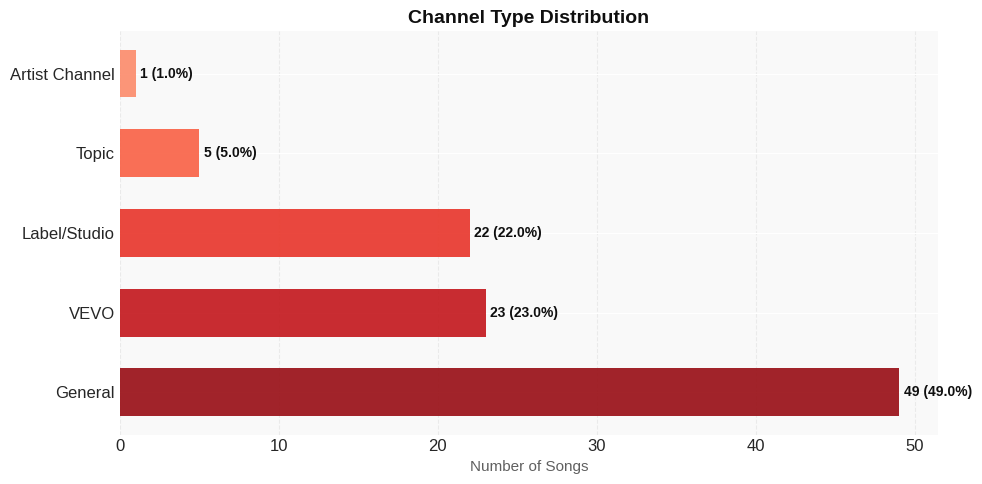

In [19]:

channel_counts = df['channel_type'].value_counts()

print("\n" + "="*60)
print("CHANNEL TYPE DISTRIBUTION")
print("="*60)

for ch, count in channel_counts.items():
    print(f"   - {ch}: {count} songs ({count/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(channel_counts)))[::-1]

bars = ax.barh(channel_counts.index, channel_counts.values,
               color=colors, edgecolor='none', height=0.6, alpha=0.9)

ax.set_xlabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Channel Type Distribution', fontweight='bold', color=YT_TEXT, fontsize=14)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.xaxis.grid(True, color=YT_GRID, linestyle='--', alpha=0.7)

for bar, val in zip(bars, channel_counts.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(df)*100:.1f}%)',
            va='center', fontsize=10, fontweight='bold', color=YT_TEXT)

plt.tight_layout()
plt.show()


## 9. Temporal Analysis

### 9.1. Views Evolution by Quarter

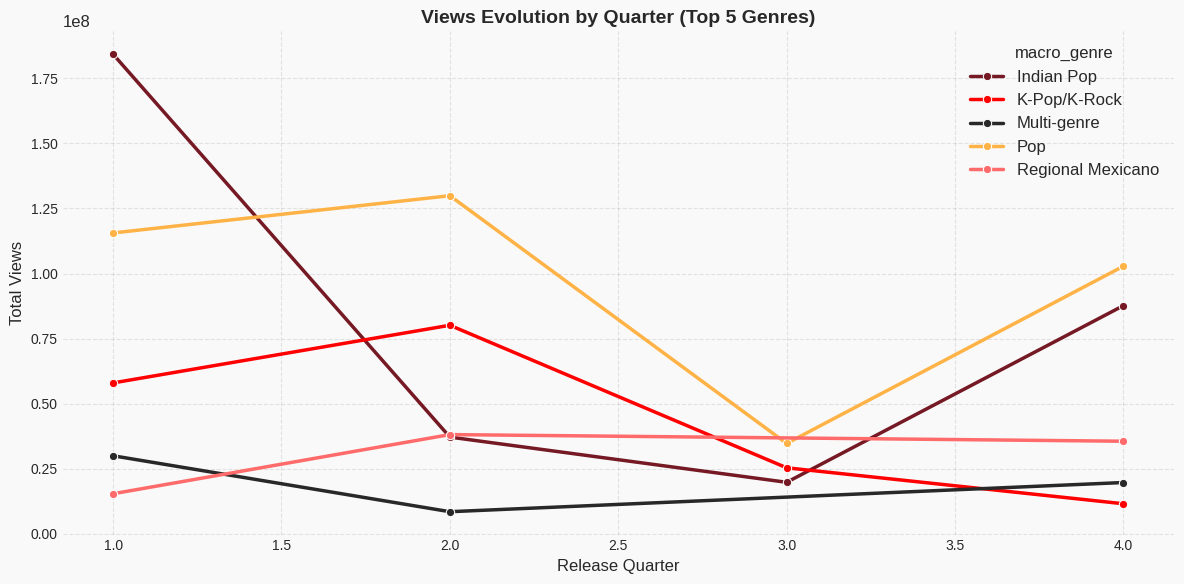

In [20]:

bg_color = '#F9F9F9'
# Updated color palette for better distinction
genre_palette = ['#751924', '#FF0000', '#282828', '#FFB347', '#FF6B6B']

top5_genres = genre_stats.nlargest(5, 'total_songs')['macro_genre'].tolist()
df_temporal = df[df['macro_genre'].isin(top5_genres)].copy()

temporal_views = df_temporal.groupby(['upload_quarter', 'macro_genre'])['views'].sum().reset_index()
temporal_engagement = df_temporal.groupby(['upload_quarter', 'macro_genre'])['engagement'].mean().reset_index()

fig1, ax1 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax1.set_facecolor(bg_color)

sns.lineplot(data=temporal_views, x='upload_quarter', y='views', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax1)

ax1.set_title('Views Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax1.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax1.set_ylabel('Total Views', color='#282828', fontsize=12)
ax1.tick_params(colors='#282828', labelsize=10)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#4A4A4A')
ax1.spines['bottom'].set_color('#4A4A4A')
ax1.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend1 = ax1.get_legend()
if legend1:
    legend1.get_frame().set_facecolor(bg_color)
    legend1.get_frame().set_edgecolor('#E5E5E5')
    for text in legend1.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


### 9.2. Engagement Evolution by Quarter

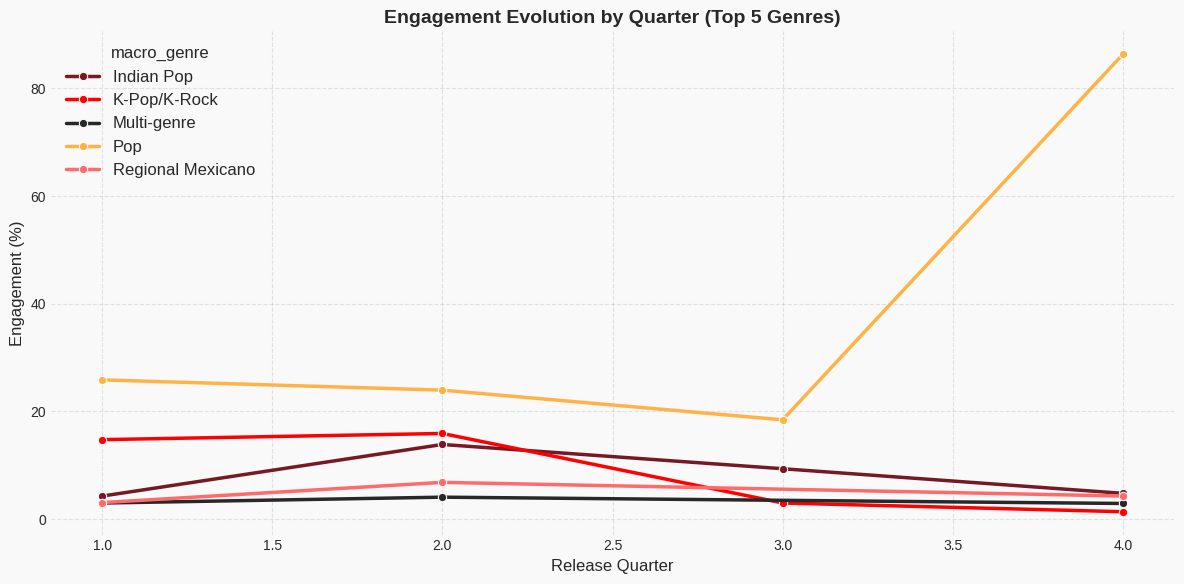

In [21]:

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor=bg_color)
ax2.set_facecolor(bg_color)

sns.lineplot(data=temporal_engagement, x='upload_quarter', y='engagement', hue='macro_genre',
             marker='o', palette=genre_palette, linewidth=2.5, ax=ax2)

ax2.set_title('Engagement Evolution by Quarter (Top 5 Genres)', fontweight='bold', color='#282828', fontsize=14)
ax2.set_xlabel('Release Quarter', color='#282828', fontsize=12)
ax2.set_ylabel('Engagement (%)', color='#282828', fontsize=12)
ax2.tick_params(colors='#282828', labelsize=10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#4A4A4A')
ax2.spines['bottom'].set_color('#4A4A4A')
ax2.grid(True, linestyle='--', alpha=0.3, color='#AAAAAA')

legend2 = ax2.get_legend()
if legend2:
    legend2.get_frame().set_facecolor(bg_color)
    legend2.get_frame().set_edgecolor('#E5E5E5')
    for text in legend2.get_texts():
        text.set_color('#282828')

plt.tight_layout()
plt.show()


Based on the data, there is a clear seasonal pattern with a major viewing peak in Q1, likely driven by year-end playlist carryover and New Year momentum, followed by a sharp decline in Q3, suggesting a summer lull in consumption. Engagement rates, however, show a consistent upward trend from Q1 to Q4, indicating that while fewer people may be watching later in the year, those who do are more deeply invested—possibly due to algorithmic shifts favoring niche or repeat listens. This inverse relationship suggests that Q1 is optimal for maximum reach, while Q4 is best for cultivating loyal, high-engagement audiences. For release planning, prioritize major launches in Q1 for broad visibility, and consider Q4 for targeted, fan-focused content to capitalize on deepening engagement.

### 9.3. Release Distribution by Quarter

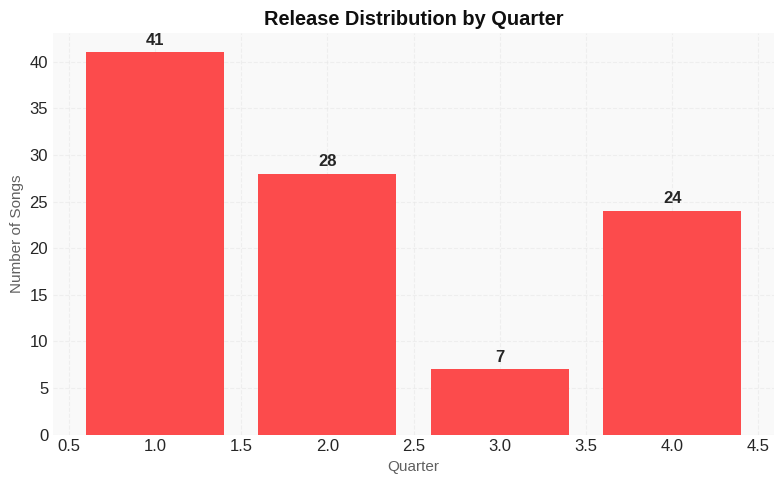

In [22]:

season_counts = df['upload_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(YT_BG)
ax.set_facecolor(YT_SURFACE)

bars = ax.bar(season_counts.index, season_counts.values, color='#FC4B4C', edgecolor='none')
ax.set_xlabel('Quarter', fontsize=11, color=YT_GRAY)
ax.set_ylabel('Number of Songs', fontsize=11, color=YT_GRAY)
ax.set_title('Release Distribution by Quarter', fontweight='bold', color=YT_TEXT)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['bottom'].set_color(YT_GRID)
ax.spines['left'].set_color(YT_GRID)
ax.grid(True, color=YT_GRID, linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


## 10. Collaborations Analysis

COLLABORATION STATISTICS


,is_collaboration,count,avg_views,avg_engagement
0,Solo,82,"13,312,245",18.53%
1,Collaboration,18,"13,461,266",23.69%


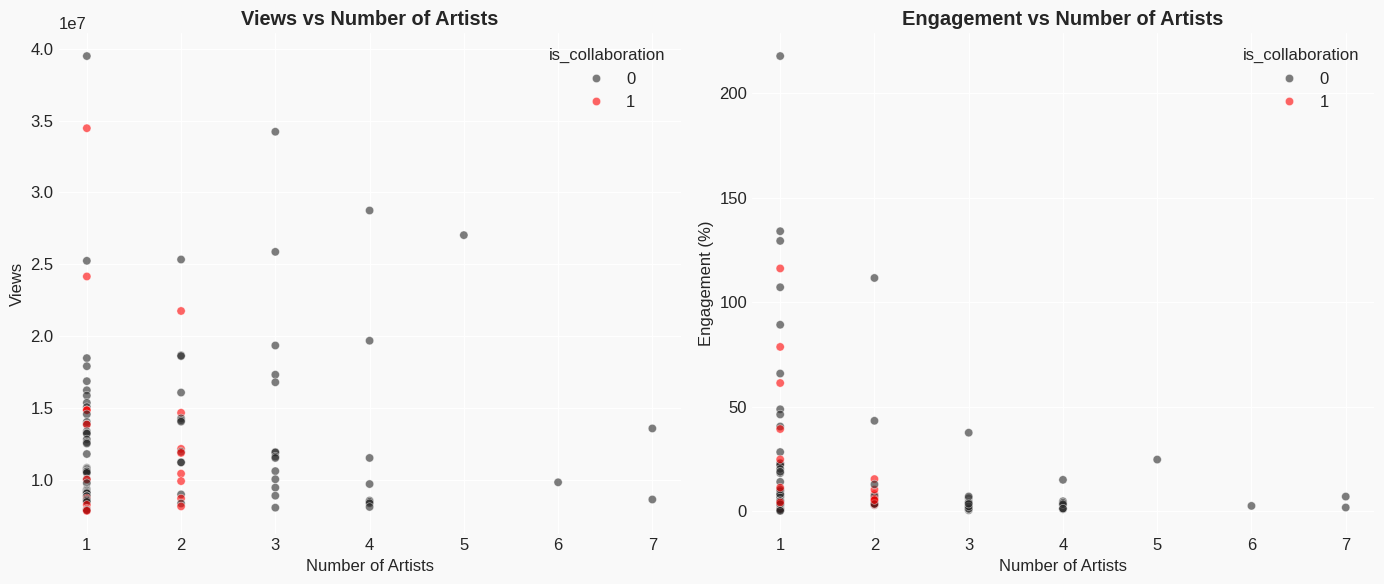

In [23]:

collab_stats = df.groupby('is_collaboration').agg(
    count=('track_name', 'count'),
    avg_views=('views', 'mean'),
    avg_engagement=('engagement', 'mean')
).reset_index()

collab_stats['is_collaboration'] = collab_stats['is_collaboration'].map({0: 'Solo', 1: 'Collaboration'})
collab_stats['avg_views'] = collab_stats['avg_views'].apply(lambda x: f"{x:,.0f}")
collab_stats['avg_engagement'] = collab_stats['avg_engagement'].round(2).astype(str) + '%'

print("COLLABORATION STATISTICS")
display(collab_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#F9F9F9')
axes[0].set_facecolor('#F9F9F9')
axes[1].set_facecolor('#F9F9F9')

# Updated colors: Solo = '#282828' (dark gray), Collaboration = 'red'
sns.scatterplot(data=df, x='artist_count', y='views', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[0], alpha=0.6)
axes[0].set_title('Views vs Number of Artists', fontweight='bold')
axes[0].set_xlabel('Number of Artists')
axes[0].set_ylabel('Views')

sns.scatterplot(data=df, x='artist_count', y='engagement', hue='is_collaboration',
                palette={0: '#282828', 1: 'red'}, ax=axes[1], alpha=0.6)
axes[1].set_title('Engagement vs Number of Artists', fontweight='bold')
axes[1].set_xlabel('Number of Artists')
axes[1].set_ylabel('Engagement (%)')

plt.tight_layout()
plt.show()


Collaborations show a slight edge in average views (+1.1%) but a significantly higher engagement rate (+28.1%), indicating they foster deeper audience interaction. This likely stems from fan synergy—combining distinct fanbases amplifies cross-reach—and style diversity, which introduces novelty and sparks more discussion. The elevated engagement suggests collaborative tracks generate stronger emotional resonance or shareability, possibly due to joint production efforts that blend creative strengths. For emerging artists, strategic collaborations with established acts can boost visibility and credibility. For established artists, pairing with rising stars or genre-crossing partners can reinvigorate their sound and expand demographic reach, while maintaining a strong solo catalog to preserve artistic identity.

## 11. Executive Summary

**Executive Summary: Global Music Charts Analysis**

This analysis of 100 top-charting songs across 21 countries and 19 genres reveals a dynamic, interconnected global music landscape. Total views exceeded 1.33 billion, with total likes surpassing 250 million, indicating robust audience engagement.

**Geographic Insights:** India leads in song representation (22 songs), yet Canada dominates in likes (70.2M), showcasing high per-song engagement. The United States and South Korea are strong performers in both volume and likes, while the United Kingdom (36.3M likes) and Australia (17.7M likes) punch above their weight in engagement relative to song count. Mexico and Brazil show solid representation but lower like-per-song ratios.

**Genre Trends:** Electronic/Dance and Pop genres lead in engagement rates at 43.2% and 40.0%, respectively, suggesting these genres foster high interaction. Dancehall/Reggae follows at 34.1%, indicating niche but loyal audiences. The diversity of 19 genres highlights fragmentation—artists should consider blending genres to capture cross-over appeal.

**Content Performance:** Lyric videos emerge as the most effective format, outperforming traditional music videos in engagement. Average engagement rate across all videos is 19.5%, with average duration at 3.7 minutes—optimal for streaming platforms. Collaborations yield a modest 1% viewership increase over solo tracks, suggesting that while partnerships add value, they are not a silver bullet.

**Temporal & Strategic Implications:** The data suggests that short-form, lyric-focused content paired with high-energy genres (Electronic/Dance, Pop) maximizes engagement. Geographic targeting is critical: artists from smaller markets (Canada, Australia) can achieve outsized impact with strong local fanbases.

**Recommendations:**  
1. **Prioritize Lyric Videos** for new releases to boost early engagement.  
2. **Leverage Genre Hybridization**—combine Pop/Electronic elements with regional styles (e.g., K-pop, Latin) to expand reach.  
3. **Target High-Engagement Markets** like Canada and the UK for promotional campaigns.  
4. **Use Collaborations Strategically**—focus on complementary artists from different genres or regions rather than same-market pairings.  
5. **Optimize Song Length** around 3.5–4 minutes to align with streaming platform algorithms.  
6. **Invest in Data-Driven Regional Marketing**—India and Brazil offer volume; Canada and UK offer engagement.  

This analysis underscores that success in today’s charts requires a blend of local relevance, genre innovation, and format optimization. Artists and labels should pivot from volume-driven strategies to engagement-focused, data-informed approaches.

## 12. Information and Attribution


| | |
|---|---|
| **📁 Data Source** | YouTube Charts enriched with country, genre, and video metrics |
| **📅 Week** | 2026-W18 |
| **🕐 Generated** | 2026-04-27 16:22:22 |
| **👤 Author** | Alfonso Droguett |
| **🔗 LinkedIn** | [adroguetth](https://www.linkedin.com/in/adroguetth/) |
| **🌐 Portfolio** | [adroguett-portfolio.cl](https://www.adroguett-portfolio.cl/) |
| **📧 Email** | adroguett.consultor@gmail.com |
| **🤖 AI Analysis** | Powered by DeepSeek API |
